In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect('/Users/navaldhandha/Library/CloudStorage/GoogleDrive-dhandhanaval@gmail.com/My Drive/Invoice_inventory_intelligence/data/inventory.db')
tables = pd.read_sql_query('select name from sqlite_master where type = "table"',conn)
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [5]:
for table in tables['name']:
    print(table)
    df = pd.read_sql_query(f'select * from {table} limit 5',conn)
    display(df)

purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [6]:
vendor_df = pd.read_sql_query('select * from vendor_invoice',conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [7]:
vendor_df[['Quantity','Dollars','Freight']].corr()

,Quantity,Dollars,Freight
Quantity,1.000000,0.963831,0.946550
Dollars,0.963831,1.000000,0.985141
Freight,0.946550,0.985141,1.000000


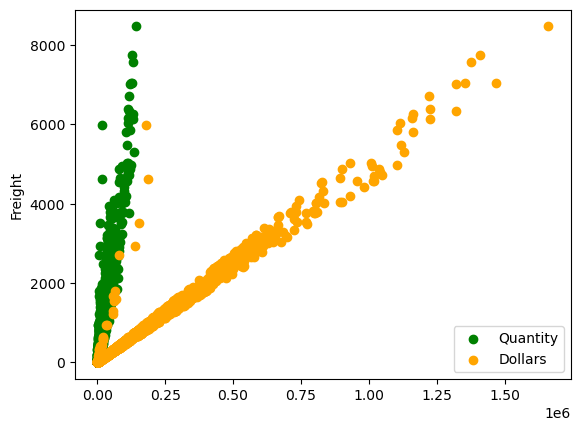

In [9]:
plt.scatter(vendor_df['Quantity'],vendor_df['Freight'],color = 'Green')
plt.scatter(vendor_df['Dollars'],vendor_df['Freight'],color = 'Orange')
plt.legend(['Quantity','Dollars'])
plt.ylabel('Freight')
plt.show()

In [11]:
vendor_df['per_unit_freight'] = vendor_df['Freight']/vendor_df['Quantity']

In [12]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
vendor_df.loc[vendor_df['Quantity']<low_quantity,'per_unit_freight'].mean()

0.09489854253138316

In [13]:
high_quantity = vendor_df['Quantity'].quantile(0.75)
vendor_df.loc[vendor_df['Quantity']>high_quantity,'per_unit_freight'].mean()

0.049077654690759046

In [15]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,per_unit_freight
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [16]:
X = vendor_df[['Quantity','Dollars']]
y = vendor_df['Freight']

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
m1 = LinearRegression()
m1.fit(X_train,y_train)

m2 = DecisionTreeRegressor(random_state = 42)
m2.fit(X_train,y_train)

m3 = RandomForestRegressor(random_state = 42)
m3.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [24]:
def model_evaluation(model,X_test,y_test,model_name):
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test,preds)
    mse = mean_squared_error(y_test,preds, squared = False)
    r2 = r2_score(y_test,preds)*100
    
    print(model_name)
    print(f'MAE : {mae}')
    print(f'MSE : {mse}')
    print(f'R^2 : {r2:.2f}%')


In [25]:
model_evaluation(m1,X_test,y_test,'Linear Regression')
model_evaluation(m2,X_test,y_test,'Decision Tree')
model_evaluation(m3,X_test,y_test,'Random Forest')

Linear Regression
MAE : 24.45918076526329
MSE : 124.42878471171811
R^2 : 97.00%
Decision Tree
MAE : 34.73715086163711
MSE : 180.8824588766438
R^2 : 93.66%
Random Forest
MAE : 27.641013163231545
MSE : 138.61379097161858
R^2 : 96.28%


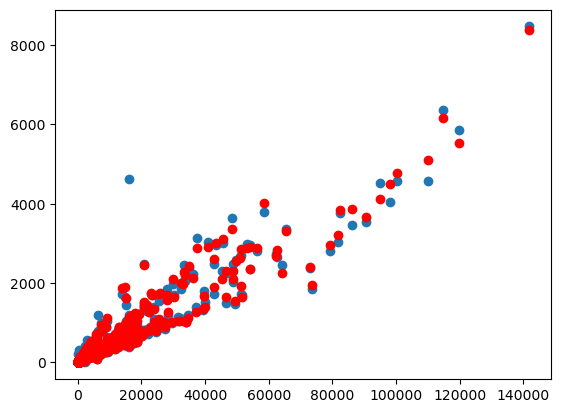

In [32]:
plt.scatter(X_test.iloc[:,0],y_test)
plt.scatter(X_test.iloc[:,0],m1.predict(X_test),color = 'red')

In [33]:
input_data = {'Quantity':[6700,450],'Dollars':[18650,9500]}
df = pd.DataFrame(input_data)

In [34]:
m1.predict(df)

array([89.4634097 , 54.24083621])